## Hand classification
First, we check the version of Tensorflow and set the seeds for reproducibility.

In [ ]:
import tensorflow as tf
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm

seed = 42

def set_seed(seedValue=42):
  """Sets the seed on multiple python modules to obtain results as
  reproducible as possible.
  Args:
  seedValue (int, optional): seed value.
  """
  np.random.seed(seed=seedValue)
  tf.random.set_seed(seedValue)
  os.environ["PYTHONHASHSEED"]=str(seedValue)
  random.seed(seedValue)
set_seed(seed)
print("Tensorflow version: ", tf.__version__ )

Tensorflow version:  2.11.0


## Utilities
(functions and classes)

### custom data-class

In [ ]:
from random import random
from glob import glob

class Data(tf.keras.utils.Sequence):
    """Helper to iterate over the data (as Numpy arrays)."""

    def __init__(self, batch_size, input_img_paths, labels, data_augmentation = False, shuffle = True):
        self.batch_size = batch_size
        self.input_img_paths = input_img_paths
        self.data_augmentation = data_augmentation
        self.labels = labels
        self.idx_map = np.array([i for i in range(len(labels))])
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.idx_map)

    def __len__(self):
        return len(self.input_img_paths) // self.batch_size

    def get_labels(self):
        return self.labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.idx_map)

    def __getitem__(self, idx):
        """Returns tuple (input, target) correspond to batch #idx."""
        i = idx * self.batch_size
        batch_input_img_paths = [self.input_img_paths[self.idx_map[j]] for j in range(i, i + self.batch_size) ]
        batch_input_labels = [self.labels[self.idx_map[j]] for j in range(i, i + self.batch_size) ]

        #x = np.zeros((self.batch_size,) + self.img_size + (3,), dtype="uint8")
        #y = np.zeros((self.batch_size,) + (1,), dtype="float32")
        x,y = [], []

        for j in range(len(batch_input_img_paths)):
            x_path = batch_input_img_paths[j]
            x_image = Image.open(x_path)
            w,h = x_image.size

            if self.data_augmentation:
                if random() < 0.5:
                    factor = random() * 2
                    if random() < 0.5:
                        # increase
                        new_dims = [round(h * factor), round(w * factor)]
                    else:
                        # decrease
                        new_dims = [round(h / factor), round(w / factor)]

                    x_image = x_image.resize(new_dims, resample=Image.NEAREST )

            x.append(np.array(x_image, dtype='float32') / 255)
            y.append(np.array(batch_input_labels[j], dtype='float32'))

            x_image.close()
        return np.array(x), np.array(y)

def get_image_path_list(directory):

    # Read the list of file names
    male = glob(directory+'Male/*.*')
    male.sort()

    female = glob(directory+'Female/*.*')
    female.sort()

    return male + female, [1]*len(male) + [0]*len(female)


### Functions to display

In [ ]:
def plot_loss_and_metric(eval_metric, history, fig_size = (14,5)):
    plt.figure(figsize=fig_size)

    if callable( eval_metric ):
        metric_name = eval_metric.__name__
    else:
        metric_name = eval_metric

    # summarize history for loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    # summarize history for MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history[metric_name])
    plt.plot(history.history['val_'+metric_name])
    plt.title('model ' + metric_name)
    plt.ylabel(metric_name)
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.show()

In [ ]:
def display(display_list, fig_size = (14,5)):
  plt.figure(figsize=fig_size)

  title = ['Image', 'Mix Image', 'Heatmap Image']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
    #print(display_list[i]) # raw image values
    #print("---------")
    #plt.axis('off')
  plt.show()


In [ ]:
sigmoid = lambda x : 1/(1 + np.exp(-x))
label2tag = {0:"Female", 1:"Male"}

def show_predictions(dataset=None, num=1, var=0):
    if dataset:
        for i in range(num):
            ind = var + i
            img, l = dataset[ind]
            pred_label = model.predict(img)
            display([img[0]])
            print("Real label:", label2tag[round(l[0][0])])
            pred = 1 if sigmoid(pred_label)>0.5 else 0
            print("Pred label: {} ({})".format( label2tag[pred],
                                           round(sigmoid(pred_label[0][0]), 5)))
    else:
        try:
            pred_label = model.predict(sample_image[tf.newaxis, ...])
            display([sample_image])
            print("Real label:", label2tag[round(sample_label[0])])
            pred = 1 if sigmoid(pred_label)>0.5 else 0
            print("Pred label: {} ({})".format( label2tag[pred],
                                            round(sigmoid(pred_label[0][0]), 5)))
        except Exception as e: 
            print(e)
            
def view_layers(model):
    for i, layer in enumerate(model.layers):
        print("{:^3} {:<20} {}".format(i, layer.name, layer.trainable))

### Others

One-cycle policy for super-convergence
We implement the learning rate on a one-cycle policy as per Leslie Smith's paper (https://arxiv.org/pdf/1803.09820.pdf) for fast convergence.

In [ ]:
import logging

logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.callbacks import Callback

class CosineAnnealer:

    def __init__(self, start, end, steps):
        self.start = start
        self.end = end
        self.steps = steps
        self.n = 0

    def step(self):
        self.n += 1
        cos = np.cos(np.pi * (self.n / self.steps)) + 1
        return self.end + (self.start - self.end) / 2. * cos


class OneCycleScheduler(Callback):
    """ `Callback` that schedules the learning rate on a 1cycle policy as per Leslie Smith's paper(https://arxiv.org/pdf/1803.09820.pdf).
    If the model supports a momentum parameter, it will also be adapted by the schedule.
    The implementation adopts additional improvements as per the fastai library: https://docs.fast.ai/callbacks.one_cycle.html, where
    only two phases are used and the adaptation is done using cosine annealing.
    In phase 1 the LR increases from `lr_max / div_factor` to `lr_max` and momentum decreases from `mom_max` to `mom_min`.
    In the second phase the LR decreases from `lr_max` to `lr_max / (div_factor * 1e4)` and momemtum from `mom_max` to `mom_min`.
    By default the phases are not of equal length, with the phase 1 percentage controlled by the parameter `phase_1_pct`.
    """

    def __init__(self, lr_max, steps, mom_min=0.85, mom_max=0.95, phase_1_pct=0.3, div_factor=25.):
        super(OneCycleScheduler, self).__init__()
        lr_min = lr_max / div_factor
        final_lr = lr_max / (div_factor * 1e4)
        phase_1_steps = steps * phase_1_pct
        phase_2_steps = steps - phase_1_steps

        self.phase_1_steps = phase_1_steps
        self.phase_2_steps = phase_2_steps
        self.phase = 0
        self.step = 0

        self.phases = [[CosineAnnealer(lr_min, lr_max, phase_1_steps), CosineAnnealer(mom_max, mom_min, phase_1_steps)],
                 [CosineAnnealer(lr_max, final_lr, phase_2_steps), CosineAnnealer(mom_min, mom_max, phase_2_steps)]]

        self.lrs = []
        self.moms = []

    def on_train_begin(self, logs=None):
        self.phase = 0
        self.step = 0

        self.set_lr(self.lr_schedule().start)
        self.set_momentum(self.mom_schedule().start)

    def on_train_batch_begin(self, batch, logs=None):
        self.lrs.append(self.get_lr())
        self.moms.append(self.get_momentum())

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        if self.step >= self.phase_1_steps:
            self.phase = 1

        self.set_lr(self.lr_schedule().step())
        self.set_momentum(self.mom_schedule().step())

    def get_lr(self):
        try:
            return tf.keras.backend.get_value(self.model.optimizer.lr)
        except AttributeError:
            return None

    def get_momentum(self):
        try:
            return tf.keras.backend.get_value(self.model.optimizer.momentum)
        except AttributeError:
            return None

    def set_lr(self, lr):
        try:
            tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        except AttributeError:
            pass # ignore

    def set_momentum(self, mom):
        try:
            tf.keras.backend.set_value(self.model.optimizer.momentum, mom)
        except AttributeError:
            pass # ignore

    def lr_schedule(self):
        return self.phases[self.phase][0]

    def mom_schedule(self):
        return self.phases[self.phase][1]

    def plot(self):
        ax = plt.subplot(1, 2, 1)
        ax.plot(self.lrs)
        ax.set_title('Learning Rate')
        ax = plt.subplot(1, 2, 2)
        ax.plot(self.moms)
        ax.set_title('Momentum')

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

def custom_eval(model, test_dataset):
    pred = []
    orig = []
    for i in tqdm(range(len(test_dataset))):
        x,y = test_dataset[i]
        prediction = model.predict_on_batch(x)
        #print(prediction)
        for j in range(len(prediction)):
            pred_label = 1 if sigmoid(prediction[j][0])>0.5 else 0
            pred.append( pred_label )
            orig.append( int(y[j]) )
    test_acc = accuracy_score(orig, pred)
    test_f1 = f1_score(orig, pred)
    test_prec = precision_score(orig, pred)
    test_rec = recall_score(orig, pred)
    conf_mat = confusion_matrix(orig, pred)
    print("\n\n",conf_mat)
    print(classification_report(orig, pred))

    return test_acc, test_f1, test_prec, test_rec

In [ ]:
def custom_eval2(model, test_dataset):
    pred = []
    orig = []
    for i in tqdm(range(len(test_dataset))):
        x,y = test_dataset[i]
        prediction = model.predict_on_batch(x)
        prediction = np.argmax(prediction, axis=1)
        for j in range(len(prediction)):
            pred.append( int(prediction[j]) )
            orig.append( int(y[j]) )
    test_acc = accuracy_score(orig, pred)
    test_f1 = f1_score(orig, pred)
    test_prec = precision_score(orig, pred)
    test_rec = recall_score(orig, pred)
    #conf_mat = confusion_matrix(orig, pred)
    #print("\n\n",conf_mat)
    print(classification_report(orig, pred))

    return test_acc, test_f1, test_prec, test_rec

In [ ]:
import scipy
def get_ci_randSeed(test_accuracies, confidence, rounds):
    # source: https://sebastianraschka.com/blog/2022/confidence-intervals-for-ml.html#conclusion

    t_value = scipy.stats.t.ppf((1 + confidence) / 2.0, df=rounds - 1)

    test_mean = np.mean(test_accuracies)

    sd = np.std(test_accuracies, ddof=1)
    se = sd / np.sqrt(rounds)

    ci_length = t_value * se

    ci_lower = test_mean - ci_length
    ci_upper = test_mean + ci_length

    return ci_lower, ci_upper, test_mean

## Network definitions

### assembly

In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model

from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Input, Activation
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.layers import AveragePooling2D

def assembly(preprocess, conv_base, head, input_shape, data_augmentation):

    inputs = Input( input_shape )

    x = inputs

    #network
    if preprocess != None: x = preprocess(x)
    if data_augmentation != None: x = data_augmentation(x)

    x = conv_base(x)
    #x = Conv2D(conv_base.output_shape[-1], activation='elu', kernel_size=(1,)*2, strides=1, padding="same")(x)
    outputs = head(x)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [ ]:
def ResNet50V2_cls_head(dropout, num_classes):
    def f(x):
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = AveragePooling2D(pool_size=8)(x)
        x = Flatten()(x)
        if dropout > 0:
            x = Dropout(dropout)(x)
        x = Dense(  num_classes,
                    #activation='softmax',
                    kernel_initializer='he_normal',
                    name = 'cls_head')(x)
        return x
    return f

In [ ]:
def ConvNext_cls_head(num_classes):
    def f(x):
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = Dense(  num_classes,
                    #activation='softmax',
                    kernel_initializer='he_normal',
                    name = 'cls_head')(x)
        return x
    return f

In [ ]:
def EffNetv2_cls_head(dropout, num_classes):
    def f(x):
        x = layers.GlobalAveragePooling2D()(x)
        if dropout > 0:
            x = Dropout(dropout)(x)
        x = Dense(  num_classes,
                    #activation='softmax',
                    kernel_initializer='he_normal',
                    name = 'cls_head')(x)
        return x
    return f

In [ ]:
def mobnetv3_cls_head(dropout, num_classes):
    def f(x):
        x = layers.GlobalAveragePooling2D(keepdims=True)(x)
        x = layers.Conv2D(
            1024,
            kernel_size=1,
            padding="same",
            use_bias=True,
            name="cls_head_0"
        )(x)
        x = Activation('relu')(x)
        if dropout > 0:
            x = layers.Dropout(dropout)(x)
        x = layers.Conv2D(num_classes, kernel_size=1, padding="same", name="cls_head")(x)
        x = layers.Flatten()(x)
        #x = layers.Activation(activation='softmax', name="Predictions")(x)
        return x
    return f

## Parameters

In [ ]:
# image size
img_size = (256,)*2
input_shape = img_size + (3,)
# last dense layer dropout
dropout = 0.0
# output neurons
num_classes = 1

resnet50v2 = {
    'conv_base': ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape = input_shape),
    'preprocess': tf.keras.applications.resnet_v2.preprocess_input,
    'head': ResNet50V2_cls_head(dropout, num_classes)
}
convnextSmall = {
    'conv_base': tf.keras.applications.convnext.ConvNeXtSmall(
        weights='imagenet',
        include_top=False,
        include_preprocessing=True,
        input_shape = input_shape),
    'preprocess': None,
    'head': ConvNext_cls_head(num_classes)
}
effnetv2S = {
    'conv_base': tf.keras.applications.efficientnet_v2.EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        include_preprocessing=True,
        input_shape = input_shape),
    'preprocess': None,
    'head': EffNetv2_cls_head(dropout, num_classes)
}
mobnetv3S = {
    'conv_base': tf.keras.applications.MobileNetV3Small(
        weights='imagenet',
        include_top=False,
        include_preprocessing=True,
        input_shape = input_shape),
    'preprocess': None,
    'head': mobnetv3_cls_head(dropout, num_classes)
}

4334752/4334752 [==============================] - 0s 0us/step


In [ ]:
# === Training parameters ===
# models to compare
# uncomment to train multiple models (sequentially)
models = {'resnet50v2': resnet50v2,
        #   'convnextSmall': convnextSmall,
        #   'effnetv2S': effnetv2S,
        #   'mobnetv3S': mobnetv3S
          }
# number of repetitions
repetitions = 3
# number of epochs
numEpochs = 5
# patience
patience = 10
# learning rate
lr = 15e-5
# use one-cycle policy for super-convergence? Reduce on plateau?
schedule = 'cos' #'oneCycle' # 'reduce' # 'cos' # None
# Optimizer name: 'Adam', 'SGD', 'rmsprop'
optimizer_name = 'Adam'
# Loss function name: 'BCE', 'Dice',
loss_acronym = 'BCE'
# Change to your desired confidence level
confidence = 0.95

# short execution only training the new last layers, (resnet finetune)
first_pre_exec = True
# short execution epochs
first_epochs = 3
# short execution learning rate
first_lr = 1e-4

# ===== Data parameters ======
# batch size
BATCH_SIZE = 6

# data augmentation
zoom_factor = 0.15
data_augmentation = None

## Prepare data

In [ ]:
custom_data_augmentation = False

paths,labels = get_image_path_list("Data_mask_keras/train/")
train_dataset = Data(BATCH_SIZE, paths, labels, data_augmentation = custom_data_augmentation, shuffle = True)

paths,labels = get_image_path_list("Data_mask_keras/val/")
val_dataset = Data(BATCH_SIZE, paths, labels, data_augmentation = custom_data_augmentation, shuffle = False)

paths,labels = get_image_path_list("Data_mask_keras/test_11k/")
test_dataset_11k = Data(BATCH_SIZE, paths, labels, data_augmentation = custom_data_augmentation, shuffle = False)

paths,labels = get_image_path_list("Data_mask_keras/test_cus/")
test_dataset_hands = Data(BATCH_SIZE, paths, labels, data_augmentation = custom_data_augmentation, shuffle = False)

paths,labels = get_image_path_list("Data_mask_keras/test_rock/")
test_dataset_rock = Data(BATCH_SIZE, paths, labels, data_augmentation = custom_data_augmentation, shuffle = False)

label2tag = {0: 'Female', 1: 'Male'}

### tf data-class

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

rescale = 1

train = ImageDataGenerator( rescale=rescale)
val = ImageDataGenerator(rescale=rescale)
test = ImageDataGenerator(rescale=rescale)

train_dataset = train.flow_from_directory("Data_mask_keras/train/",
                                          target_size= img_size,
                                          batch_size = BATCH_SIZE,
                                          class_mode = 'binary',
                                          seed = seed)

val_dataset = val.flow_from_directory("Data_mask_keras/val/",
                                          target_size= img_size,
                                          batch_size = BATCH_SIZE,
                                          class_mode = 'binary',
                                          seed = seed)

test_dataset_11k = test.flow_from_directory("Data_mask_keras/test_11k/",
                                          target_size= img_size,
                                          batch_size = BATCH_SIZE,
                                          class_mode = 'binary',
                                          seed = seed)

test_dataset_hands = test.flow_from_directory("Data_mask_keras/test_cus/",
                                          target_size= img_size,
                                          batch_size = BATCH_SIZE,
                                          class_mode = 'binary',
                                          seed = seed)

test_dataset_rock = test.flow_from_directory("Data_mask_keras/test_rock/",
                                          target_size= img_size,
                                          batch_size = BATCH_SIZE,
                                          class_mode = 'binary',
                                          seed = seed)

Found 1592 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Found 457 images belonging to 2 classes.
Found 51 images belonging to 2 classes.
Found 29 images belonging to 2 classes.


In [ ]:
label2tag = dict([(value, key) for key, value in val_dataset.class_indices.items()])# swap key an values
label2tag

{0: 'Female', 1: 'Male'}

### Display (x,y) image example
What does one downscaled input image and corresponding ground truth image look like?

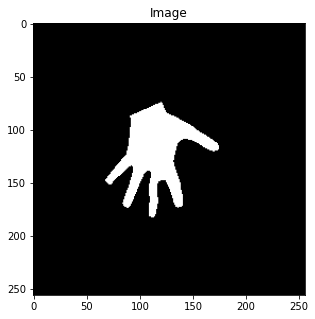

label:  1.0


In [ ]:
for i in range(1):
    sample_image, sample_label = train_dataset[i]
    sample_image, sample_label = sample_image[0], sample_label[0] # first batch image
    display([sample_image])
    print("label: ", sample_label)

In [ ]:
if data_augmentation:
    mse = tf.keras.losses.MeanSquaredError()
    da_img_list = []
    da_labels = []

    for i in range(3):
        x,y = train_dataset[i]
        da_labels.append(float(y))
        da = data_augmentation(x, training=True)
        print(mse(x, da).numpy()) # != 0 --> data augm applied
        da_img_list.append(da[0])
    print(da_labels)
    display(da_img_list)


## Compile function

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.backend import clear_session

def compile_all(model, num_classes):
    # Free up RAM in case the model definition cells were run multiple times
    clear_session()

    if loss_acronym == 'BCE':
        if num_classes == 1:
            #loss_funct = 'binary_crossentropy'
            loss_funct = tf.keras.losses.BinaryCrossentropy(from_logits=True)
        else:
            #loss_funct = 'sparse_categorical_crossentropy'
            loss_funct = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    eval_metric = ['accuracy']

    if first_pre_exec:
        # freeze everything except the cls head
        for layer in model.layers[:]:
            if layer.name[:8] != 'cls_head':
                layer.trainable = False
        #model.summary()

        # check layers
        #view_layers(model)

        # Compile frozen conv_base + new top layer
        model.compile(optimizer=optimizers.Adam(learning_rate=first_lr),
                    loss=loss_funct,
                    metrics=eval_metric)

        # Short training ONLY new top layers
        #... so the conv_base weights will not be destroyed by the random intialization of the new weights
        history = model.fit(train_dataset,
                            steps_per_epoch = np.ceil(len(train_dataset) / BATCH_SIZE),
                            epochs=first_epochs,
                            validation_data = val_dataset,)
        # unfreeze everything
        for layer in model.layers[:]:
            layer.trainable = True

        print('Warmup finished')

    #model.summary()

    if schedule == 'cos':
        decay_steps = np.ceil(len(train_dataset) / BATCH_SIZE) * numEpochs
        lr_ = tf.keras.optimizers.schedules.CosineDecay(lr, decay_steps)
    else:
        lr_ = lr

    if optimizer_name == 'SGD':
        optim =  tf.keras.optimizers.SGD(
                lr=lr_, momentum=0.99, decay=0.0, nesterov=False)
    elif optimizer_name == 'Adam':
        optim = tf.keras.optimizers.Adam( learning_rate=lr_ )
    elif optimizer_name == 'rmsprop':
        optim = tf.keras.optimizers.RMSprop( learning_rate=lr_ )

    # compile the model with the specific optimizer, loss function and metric
    model.compile(optimizer=optim, loss=loss_funct, metrics=[eval_metric])

    # callback for early stop
    earlystopper = EarlyStopping(patience=patience, verbose=1, restore_best_weights=True)

    if schedule == 'oneCycle':
        # callback for one-cycle schedule
        steps = np.ceil(len(train_dataset) / BATCH_SIZE) * numEpochs
        lr_schedule = OneCycleScheduler(lr, steps)
    elif schedule == 'reduce':
        # callback to reduce the learning rate in the plateau
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=patience, min_lr=(lr/10))
    else:
        lr_schedule = None

    callbacks = [earlystopper] if lr_schedule is None else [earlystopper, lr_schedule]
    return model, callbacks, eval_metric

In [ ]:
for m_name, m in models.items():
    print(m_name)

resnet50v2


## Train

In [ ]:
results = {}
eval_f = custom_eval if num_classes == 1 else custom_eval2

if not os.path.exists('./models/'):
    os.makedirs('./models/')

for i, aux in enumerate(models.items()):
    m_name, m = aux

    per_rep_acc_11k = []
    per_rep_f1_11k = []
    per_rep_prec_11k = []
    per_rep_rec_11k = []

    per_rep_acc_hands = []
    per_rep_f1_hands = []
    per_rep_prec_hands = []
    per_rep_rec_hands = []

    per_rep_acc_rock = []
    per_rep_f1_rock = []
    per_rep_prec_rock = []
    per_rep_rec_rock = []

    for r in range(repetitions):
        print('\n'+'-'*80)
        print("{:^80}".format("{} - MODEL: {}/{} -- REPETITION: {}/{} --- Exec: {}/{}".format(m_name, i+1, len(models), r+1, repetitions, repetitions*i+(r+1), len(models)*repetitions) ))
        print('-'*80)

        # ======= Network base ========
        model = assembly(preprocess=m['preprocess'], conv_base=m['conv_base'], head=m['head'],
                         input_shape=input_shape, data_augmentation=data_augmentation)
        # ==============================

        model, callbacks, eval_metric = compile_all(model, num_classes)

        # Train the model, doing validation at the end of each epoch.
        history = model.fit( train_dataset,
                            steps_per_epoch = np.ceil(len(train_dataset) / BATCH_SIZE),
                            validation_data=val_dataset,
                            epochs=numEpochs,
                            callbacks=callbacks)

        plot_loss_and_metric(eval_metric[0], history)
        print('TEST: 11k-dataset (test set)')
        test_acc_11k, test_f1_11k, test_prec_11k, test_rec_11k = eval_f(model, test_dataset_11k)
        print('TEST: custom hands dataset (test set)')
        test_acc_hands, test_f1_hands, test_prec_hands, test_rec_hands = eval_f(model, test_dataset_hands)
        print('TEST: rock hands dataset (test set)')
        test_acc_rock, test_f1_rock, test_prec_rock, test_rec_rock = eval_f(model, test_dataset_rock)

        # Save weights for future reuse
        #weights_filename = '/content/drive/MyDrive/Internship/models/hands/hand-classifier-weights-acc-'+str(round(np.mean(test_acc_hands),5))+'-'+loss_acronym+'-bs-'+str(BATCH_SIZE)+'-'+optimizer_name+'-'+str(img_size[0])+'x'+str(img_size[1])+'.h5'
        #model.save( weights_filename )
        #print( 'Saved model as ' + weights_filename )

        del model

        per_rep_acc_11k.append( test_acc_11k )
        per_rep_f1_11k.append( test_f1_11k )
        per_rep_prec_11k.append( test_prec_11k )
        per_rep_rec_11k.append( test_rec_11k )

        per_rep_acc_hands.append( test_acc_hands )
        per_rep_f1_hands.append( test_f1_hands )
        per_rep_prec_hands.append( test_prec_hands )
        per_rep_rec_hands.append( test_rec_hands )

        per_rep_acc_rock.append( test_acc_rock )
        per_rep_f1_rock.append( test_f1_rock )
        per_rep_prec_rock.append( test_prec_rock )
        per_rep_rec_rock.append( test_rec_rock )

    ci_lower_11k, ci_upper_11k, test_mean_11k = get_ci_randSeed(per_rep_acc_11k, confidence, repetitions)
    ci_lower_hands, ci_upper_hands, test_mean_hands = get_ci_randSeed(per_rep_acc_hands, confidence, repetitions)
    ci_lower_rock, ci_upper_rock, test_mean_rock = get_ci_randSeed(per_rep_acc_rock, confidence, repetitions)

    results[m_name] = {
        '11k':{
            "Test accuracy": test_mean_11k,
            f"Lower {int(confidence*100)}% CI": ci_lower_11k,
            f"Upper {int(confidence*100)}% CI": ci_upper_11k,
            f"std": np.std(per_rep_acc_11k),
        },
        'hands':{
            "Test accuracy": test_mean_hands,
            f"Lower {int(confidence*100)}% CI": ci_lower_hands,
            f"Upper {int(confidence*100)}% CI": ci_upper_hands,
            f"std": np.std(per_rep_acc_hands),
        },
        'rock':{
            "Test accuracy": test_mean_rock,
            f"Lower {int(confidence*100)}% CI": ci_lower_rock,
            f"Upper {int(confidence*100)}% CI": ci_upper_rock,
            f"std": np.std(per_rep_acc_rock),
        }
    }
    print('-'*40)
    print(results)
    print('-'*40)


## Results

In [ ]:
# Results
#if len(models) == 1:
print('TEST results:')
print('Repetitions: ', repetitions)
print('\n11K-hands dataset (segmentation based selected subset)')
print('Test acc:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_acc_11k),  np.std(per_rep_acc_11k)  ))
print('Test f1:   {:.4f} ± {:.4f}'.format( np.mean(per_rep_f1_11k),   np.std(per_rep_f1_11k)   ))
print('Test prec: {:.4f} ± {:.4f}'.format( np.mean(per_rep_prec_11k), np.std(per_rep_prec_11k) ))
print('Test rec:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_rec_11k),  np.std(per_rep_rec_11k)  ))
print('\nHands custom dataset')
print('Test acc:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_acc_hands),  np.std(per_rep_acc_hands)  ))
print('Test f1:   {:.4f} ± {:.4f}'.format( np.mean(per_rep_f1_hands),   np.std(per_rep_f1_hands)   ))
print('Test prec: {:.4f} ± {:.4f}'.format( np.mean(per_rep_prec_hands), np.std(per_rep_prec_hands) ))
print('Test rec:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_rec_hands),  np.std(per_rep_rec_hands)  ))
print('\nRock hands dataset')
print('Test acc:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_acc_rock),  np.std(per_rep_acc_rock)  ))
print('Test f1:   {:.4f} ± {:.4f}'.format( np.mean(per_rep_f1_rock),   np.std(per_rep_f1_rock)   ))
print('Test prec: {:.4f} ± {:.4f}'.format( np.mean(per_rep_prec_rock), np.std(per_rep_prec_rock) ))
print('Test rec:  {:.4f} ± {:.4f}'.format( np.mean(per_rep_rec_rock),  np.std(per_rep_rec_rock)  ))

TEST results:
Repetitions:  3

11K-hands dataset (segmentation based selected subset)
Test acc:  0.8621 ± 0.0129
Test f1:   0.8465 ± 0.0176
Test prec: 0.8969 ± 0.0232
Test rec:  0.8034 ± 0.0414

Hands custom dataset
Test acc:  0.5556 ± 0.0245
Test f1:   0.3740 ± 0.1298
Test prec: 0.5942 ± 0.0167
Test rec:  0.2933 ± 0.1320

Rock hands dataset
Test acc:  0.5632 ± 0.0325
Test f1:   0.0833 ± 0.1179
Test prec: 0.1667 ± 0.2357
Test rec:  0.0556 ± 0.0786


In [ ]:
results

{'resnet50v2': {'11k': {'Test accuracy': 0.862144420131291,
   'Lower 95% CI': 0.82294667004216,
   'Upper 95% CI': 0.901342170220422,
   'std': 0.012883677412586204},
  'hands': {'Test accuracy': 0.5555555555555557,
   'Lower 95% CI': 0.4811519666587034,
   'Upper 95% CI': 0.629959144452408,
   'std': 0.024455277037738178},
  'rock': {'Test accuracy': 0.5632183908045977,
   'Lower 95% CI': 0.4643068337951432,
   'Upper 95% CI': 0.6621299478140522,
   'std': 0.032510656606278006}}}

In [ ]:
labels = list(results.keys())
datasets = list(results[labels[0]].keys())

for i,ds in enumerate(datasets):

    means = np.array([results[k][ds]["Test accuracy"] for k in labels])
    lower_error = np.array([results[k][ds][f"Lower {int(confidence*100)}% CI"] for k in labels])
    upper_error = np.array([results[k][ds][f"Upper {int(confidence*100)}% CI"] for k in labels])

    asymmetric_error = [means - lower_error, upper_error - means]

    plt.figure(figsize=(7, 7))

    ax = plt.subplot((len(labels)), 1, i+1)
    ax.errorbar(means, np.arange(len(means)), xerr=asymmetric_error, fmt="o")
    #ax.set_xlim([0.75, 1.0])
    ax.set_yticks(np.arange(len(means)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Prediction accuracy")
    ax.set_title(f"{ds}:   {int(confidence*100)}% confidence intervals")

    plt.grid()
    plt.tight_layout()

plt.show()